In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import parse_version
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# Reading the dataset
df = pd.read_csv(
    "../../data/data_Hw3_new.csv",
    sep=";",
    parse_dates=["Date"],
    date_format=lambda x: pd.to_datetime(x, format="%m/%d/%y %H:%M")
)
df .head()

,Date,WE_O3,AE_O3,WE_NO2,AE_NO2,Temp,RelHum,RefSt_O3
0,6/4/23 0:00,455.58,451.83,449.58,445.33,21.47,69.58,54.0
1,6/4/23 1:00,452.92,452.75,448.75,446.25,21.17,71.98,64.0
2,6/4/23 2:00,453.50,452.58,444.92,447.00,21.03,71.65,56.0
3,6/4/23 3:00,450.75,452.25,437.58,446.50,21.10,70.75,43.0
4,6/4/23 4:00,448.58,451.50,433.33,445.50,20.79,69.68,34.0


In [4]:
# Separate the information from Captor from the true values
# Captor data
X = df .iloc[:, 1:-1]
# True values
y = df .iloc[:, -1]

In [5]:
# Get the training Captor data, test Captor data, training true values and testing true values
# Use a deterministic random state for repeatable experiments
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

In [7]:
param_grid = {'max_depth': list(range(1, 25))}
gbr = ensemble.GradientBoostingRegressor(n_estimators = 500, min_samples_split = 5, learning_rate = 0.01, random_state=0)

grid = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

print("Best params:",)
print("Best CV r2:", grid.best_score_)

best_model = grid.best_estimator_
# final evaluation on the untouched test set:
test_r2 = best_model.score(X_test, y_test)
print("Test R2:", test_r2)

Best params:
Best CV r2: 0.8581871273084068
Test R2: 0.8884433970704504


In [6]:
best_depth = grid.best_params_["max_depth"]
best_depth

7

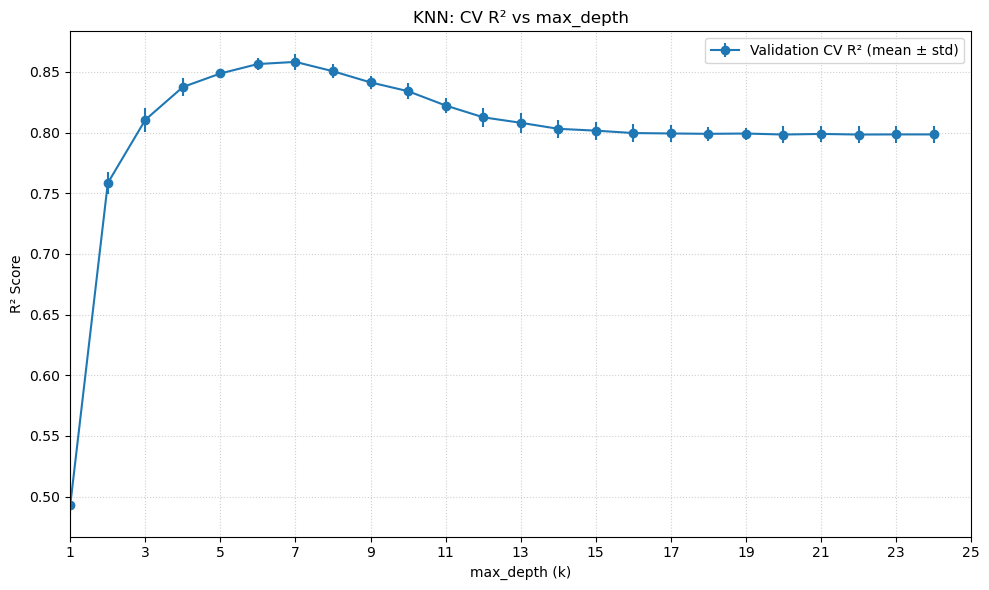

In [7]:
cv = grid.cv_results_
k_vals = np.array([int(k) for k in cv['param_max_depth']])
mean_test = cv['mean_test_score']
std_test  = cv['std_test_score']

plt.figure(figsize=(10,6))

# Validation (CV) R² curve
plt.errorbar(
    k_vals, mean_test, yerr=std_test,
    fmt='o-', label='Validation CV R² (mean ± std)'
)

plt.title("KNN: CV R² vs max_depth")
plt.xlabel("max_depth (k)")
plt.ylabel("R² Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(np.arange(1, 26, 2))
plt.xlim(1, 25)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
gbr = ensemble.GradientBoostingRegressor(n_estimators = 500, max_depth=best_depth, min_samples_split = 5, learning_rate = 0.01, random_state=0).fit(X_train, y_train)


In [13]:
y_predicted = gbr.predict(X_test)

In [14]:
r2 = r2_score(y_test, y_predicted)
r2

0.8884433970704504

In [15]:
mae = mean_absolute_error(y_test, y_predicted)
mae

5.719223379386838

In [16]:
mse = mean_squared_error(y_test, y_predicted)
rmse = float(np.sqrt(mse))
rmse

7.3902618938851825